# Phase 4: Temperature Forecasting

## Objective
Forecast daily temperature for 3 climatically-diverse cities using multiple modeling approaches, then combine them into an ensemble.

## Cities & Models
**Cities:** London (Northern temperate), New Delhi (Northern subtropical), Canberra (Southern temperate)

**Models:**
1. **ARIMA** — classical statistical baseline
2. **Seasonal Naive** — simple but powerful baseline (predict same calendar day from last year)
3. **XGBoost** — gradient boosting with engineered time features
4. **Ensemble** — simple average of all 3 forecasts

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
import xgboost as xgb
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

os.makedirs("../figures", exist_ok=True)
def save_fig(name):
    plt.savefig(f"../figures/{name}.png", dpi=120, bbox_inches='tight')

In [2]:
df = pd.read_parquet("../data/weather_cleaned.parquet")
print(f"Shape: {df.shape}")
print(f"Date range: {df['last_updated'].min()} \u2192 {df['last_updated'].max()}")

Shape: (138777, 45)
Date range: 2024-05-16 01:45:00 → 2026-05-01 19:45:00


## 1. Prepare daily time series for each city

In [3]:
target_cities = ['London', 'New Delhi', 'Canberra']

def prepare_city_series(df, city):
    sub = df[df['location_name'] == city].sort_values('last_updated').copy()
    daily = sub.set_index('last_updated')['temperature_celsius'].resample('D').mean()
    daily = daily.dropna().reset_index()
    daily.columns = ['ds', 'y']
    return daily

city_series = {city: prepare_city_series(df, city) for city in target_cities}

for city, ts in city_series.items():
    print(f"{city:12s} | {len(ts)} days | {ts['ds'].min().date()} \u2192 {ts['ds'].max().date()}")

London       | 710 days | 2024-05-16 → 2026-05-01
New Delhi    | 711 days | 2024-05-16 → 2026-05-01
Canberra     | 709 days | 2024-05-16 → 2026-05-01


## 2. Train / Test Split (80/20)

In [4]:
def train_test_split_ts(ts, train_frac=0.8):
    n = len(ts)
    train_n = int(n * train_frac)
    return ts.iloc[:train_n].copy(), ts.iloc[train_n:].copy()

splits = {city: train_test_split_ts(ts) for city, ts in city_series.items()}

for city, (train, test) in splits.items():
    print(f"{city:12s} | train: {len(train)} days | test: {len(test)} days")

London       | train: 568 days | test: 142 days
New Delhi    | train: 568 days | test: 143 days
Canberra     | train: 567 days | test: 142 days


## 3. Model 1: ARIMA

ARIMA (AutoRegressive Integrated Moving Average) is the classical statistical workhorse for time series forecasting. We use ARIMA(5,1,0) — 5 lag terms with 1st-order differencing — as a robust default.

In [5]:
def forecast_arima(train, test):
    model = ARIMA(train['y'].values, order=(5, 1, 0))
    fitted = model.fit()
    forecast = fitted.forecast(steps=len(test))
    return np.array(forecast)

arima_preds = {}
for city, (train, test) in splits.items():
    arima_preds[city] = forecast_arima(train, test)
    print(f"{city:12s} | ARIMA forecast complete ({len(arima_preds[city])} days)")

London       | ARIMA forecast complete (142 days)
New Delhi    | ARIMA forecast complete (143 days)
Canberra     | ARIMA forecast complete (142 days)


## 4. Model 2: Seasonal Naive

A surprisingly strong baseline for seasonal time series. It predicts each day's temperature as equal to the temperature **exactly 365 days earlier**. Captures yearly seasonality without any training. In weather forecasting, this baseline is famously hard to beat.

In [6]:
def forecast_seasonal_naive(train, test, season_length=365):
    full = pd.concat([train, test]).reset_index(drop=True)
    preds = []
    for i in range(len(train), len(full)):
        if i - season_length >= 0:
            preds.append(full['y'].iloc[i - season_length])
        else:
            preds.append(train['y'].mean())
    return np.array(preds)

snaive_preds = {}
for city, (train, test) in splits.items():
    snaive_preds[city] = forecast_seasonal_naive(train, test)
    print(f"{city:12s} | Seasonal Naive forecast complete ({len(snaive_preds[city])} days)")

London       | Seasonal Naive forecast complete (142 days)
New Delhi    | Seasonal Naive forecast complete (143 days)
Canberra     | Seasonal Naive forecast complete (142 days)


## 5. Model 3: XGBoost (with engineered time features)

In [7]:
def make_xgb_features(ts):
    out = ts.copy()
    out['day_of_year'] = out['ds'].dt.dayofyear
    out['month'] = out['ds'].dt.month
    out['doy_sin'] = np.sin(2 * np.pi * out['day_of_year'] / 365)
    out['doy_cos'] = np.cos(2 * np.pi * out['day_of_year'] / 365)
    out['lag_1'] = out['y'].shift(1)
    out['lag_7'] = out['y'].shift(7)
    return out

def forecast_xgboost(train, test):
    full = pd.concat([train, test]).reset_index(drop=True)
    full = make_xgb_features(full)
    feature_cols = ['day_of_year', 'month', 'doy_sin', 'doy_cos', 'lag_1', 'lag_7']

    train_features = full.iloc[:len(train)].dropna()
    X_train = train_features[feature_cols]
    y_train = train_features['y']

    model = xgb.XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05,
                              random_state=42, verbosity=0)
    model.fit(X_train, y_train)

    preds = []
    history = full.copy()
    for i in range(len(train), len(full)):
        row_features = history.iloc[[i]][feature_cols]
        if row_features.isnull().any().any():
            row_features = row_features.fillna(method='ffill', axis=1).fillna(y_train.mean())
        pred = model.predict(row_features)[0]
        preds.append(pred)
        history.loc[i, 'y'] = pred
        if i + 1 < len(history):
            history.loc[i+1, 'lag_1'] = pred
        if i + 7 < len(history):
            history.loc[i+7, 'lag_7'] = pred
    return np.array(preds)

xgb_preds = {}
for city, (train, test) in splits.items():
    xgb_preds[city] = forecast_xgboost(train, test)
    print(f"{city:12s} | XGBoost forecast complete ({len(xgb_preds[city])} days)")

London       | XGBoost forecast complete (142 days)
New Delhi    | XGBoost forecast complete (143 days)
Canberra     | XGBoost forecast complete (142 days)


## 6. Ensemble — Simple Average

In [8]:
ensemble_preds = {}
for city in target_cities:
    ensemble_preds[city] = (arima_preds[city] + snaive_preds[city] + xgb_preds[city]) / 3
    print(f"{city:12s} | Ensemble created")

London       | Ensemble created
New Delhi    | Ensemble created
Canberra     | Ensemble created


## 7. Evaluate all models — MAE & RMSE

In [9]:
def evaluate(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    return mae, rmse

results = []
for city in target_cities:
    _, test = splits[city]
    actual = test['y'].values
    for model_name, preds in [('ARIMA', arima_preds[city]),
                               ('Seasonal Naive', snaive_preds[city]),
                               ('XGBoost', xgb_preds[city]),
                               ('Ensemble', ensemble_preds[city])]:
        mae, rmse = evaluate(actual, preds)
        results.append({'City': city, 'Model': model_name, 'MAE': round(mae, 2), 'RMSE': round(rmse, 2)})

results_df = pd.DataFrame(results)
print("\nForecast Performance Summary (MAE):")
print("="*60)
print(results_df.pivot(index='City', columns='Model', values='MAE').round(2).to_string())
print("\nLower MAE = better model")


Forecast Performance Summary (MAE):
Model      ARIMA  Ensemble  Seasonal Naive  XGBoost
City                                               
Canberra    5.80      5.24            7.65     7.07
London      3.40      2.99            3.49     3.36
New Delhi   6.93      3.64            4.12     3.52

Lower MAE = better model


In [10]:
print("\nFull comparison (MAE & RMSE):\n")
pivot_mae = results_df.pivot(index='City', columns='Model', values='MAE')
pivot_rmse = results_df.pivot(index='City', columns='Model', values='RMSE')
combined = pd.concat({'MAE': pivot_mae, 'RMSE': pivot_rmse}, axis=1)
print(combined.round(2).to_string())


Full comparison (MAE & RMSE):

            MAE                                  RMSE                                
Model     ARIMA Ensemble Seasonal Naive XGBoost ARIMA Ensemble Seasonal Naive XGBoost
City                                                                                 
Canberra   5.80     5.24           7.65    7.07  6.77     6.67           9.38    8.78
London     3.40     2.99           3.49    3.36  4.31     3.80           4.55    4.08
New Delhi  6.93     3.64           4.12    3.52  8.50     4.47           5.18    4.52


## 8. Visual Comparison — Actual vs Predicted

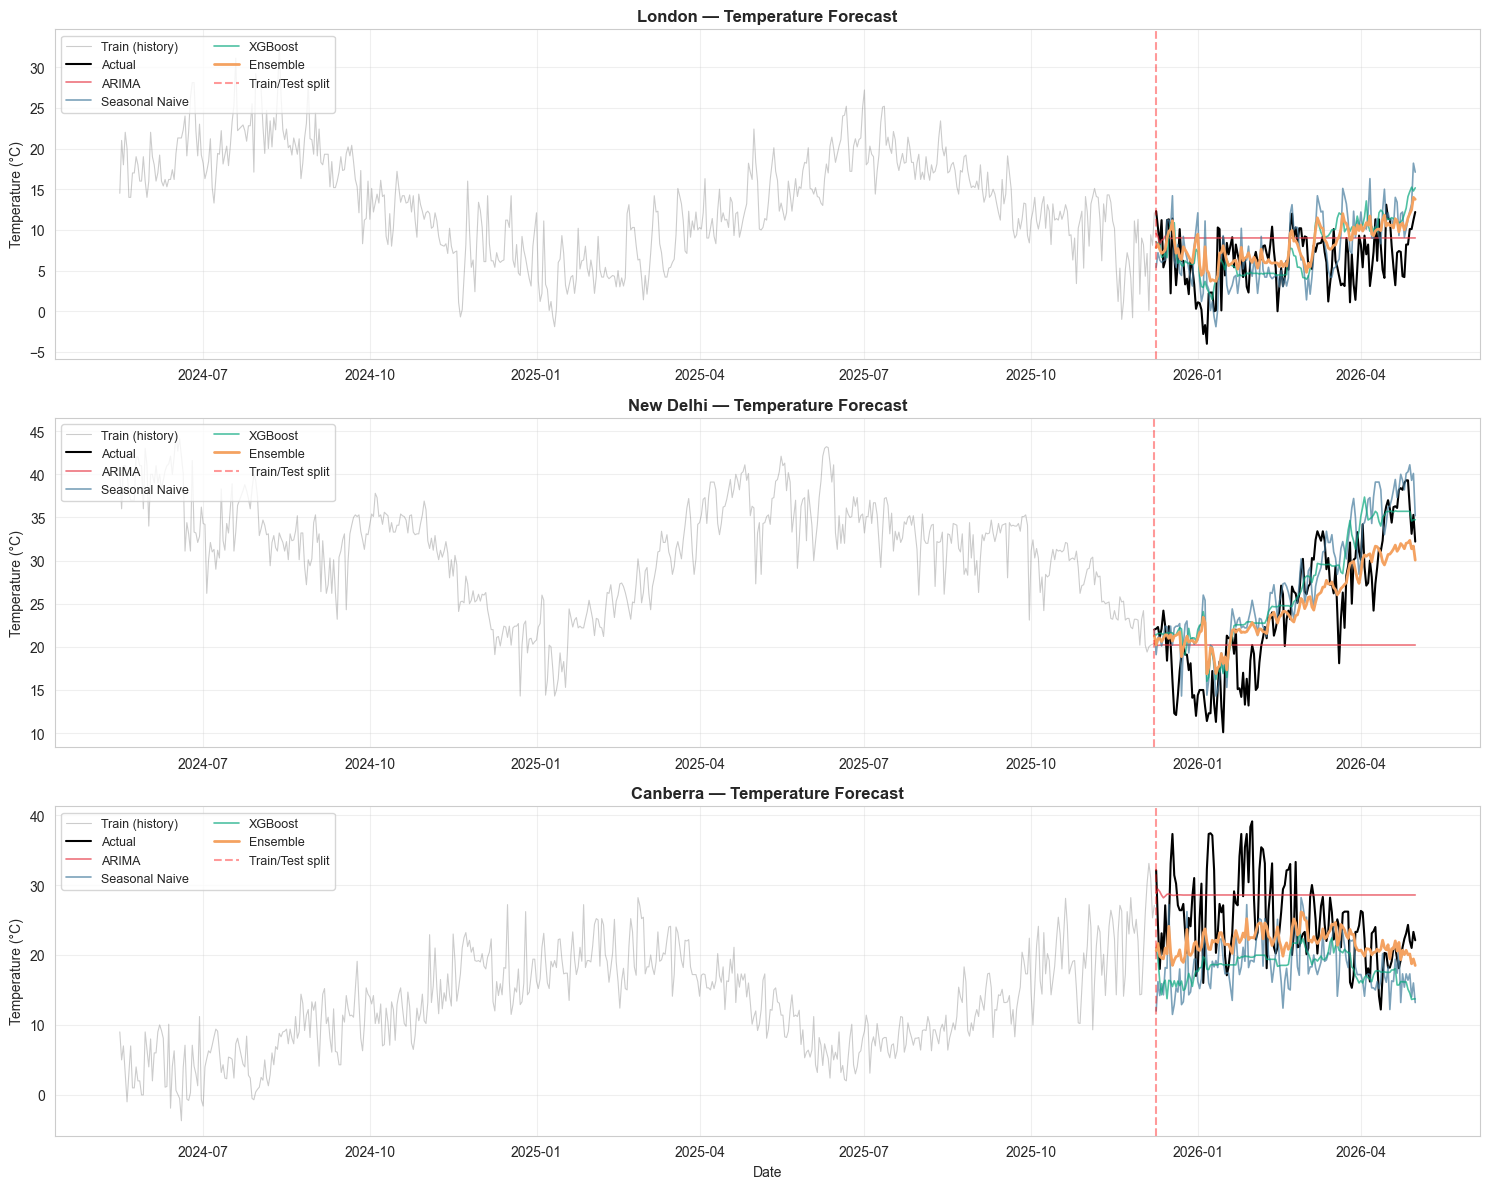

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

for ax, city in zip(axes, target_cities):
    train, test = splits[city]
    ax.plot(train['ds'], train['y'], color='gray', alpha=0.4, label='Train (history)', linewidth=0.8)
    ax.plot(test['ds'], test['y'], color='black', linewidth=1.5, label='Actual')
    ax.plot(test['ds'], arima_preds[city], color='#E63946', linewidth=1.2, alpha=0.7, label='ARIMA')
    ax.plot(test['ds'], snaive_preds[city], color='#457B9D', linewidth=1.2, alpha=0.7, label='Seasonal Naive')
    ax.plot(test['ds'], xgb_preds[city], color='#06A77D', linewidth=1.2, alpha=0.7, label='XGBoost')
    ax.plot(test['ds'], ensemble_preds[city], color='#F4A261', linewidth=2, label='Ensemble')
    ax.axvline(x=test['ds'].iloc[0], color='red', linestyle='--', alpha=0.4, label='Train/Test split')

    ax.set_title(f'{city} \u2014 Temperature Forecast', fontweight='bold')
    ax.set_ylabel('Temperature (\u00b0C)')
    ax.legend(loc='upper left', fontsize=9, ncol=2)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Date')
plt.tight_layout()
save_fig('phase4_forecast_comparison')
plt.show()

## 9. Performance Bar Chart

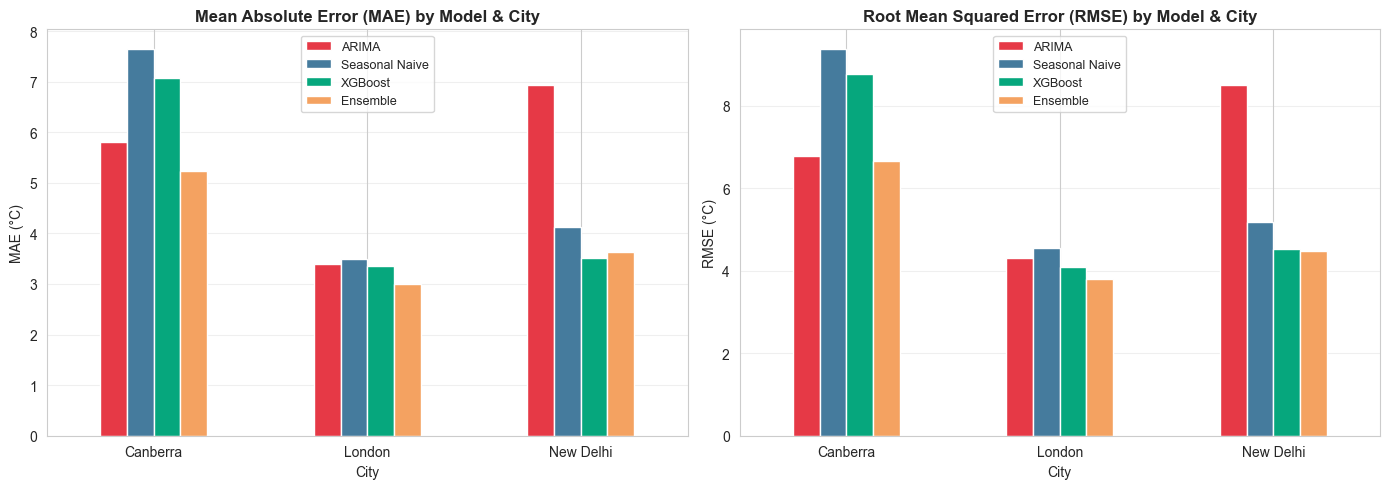

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_order = ['ARIMA', 'Seasonal Naive', 'XGBoost', 'Ensemble']
colors = ['#E63946', '#457B9D', '#06A77D', '#F4A261']

pivot_mae_p = results_df.pivot(index='City', columns='Model', values='MAE')[model_order]
pivot_mae_p.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Mean Absolute Error (MAE) by Model & City', fontweight='bold')
axes[0].set_ylabel('MAE (\u00b0C)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3, axis='y')

pivot_rmse_p = results_df.pivot(index='City', columns='Model', values='RMSE')[model_order]
pivot_rmse_p.plot(kind='bar', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('Root Mean Squared Error (RMSE) by Model & City', fontweight='bold')
axes[1].set_ylabel('RMSE (\u00b0C)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
save_fig('phase4_model_performance')
plt.show()

## 10. Save results

In [13]:
results_df.to_csv("../data/forecast_results.csv", index=False)
print("\u2705 Saved forecast performance metrics to data/forecast_results.csv")
print("\nFinal Results:")
print(results_df.to_string(index=False))

✅ Saved forecast performance metrics to data/forecast_results.csv

Final Results:
     City          Model  MAE  RMSE
   London          ARIMA 3.40  4.31
   London Seasonal Naive 3.49  4.55
   London        XGBoost 3.36  4.08
   London       Ensemble 2.99  3.80
New Delhi          ARIMA 6.93  8.50
New Delhi Seasonal Naive 4.12  5.18
New Delhi        XGBoost 3.52  4.52
New Delhi       Ensemble 3.64  4.47
 Canberra          ARIMA 5.80  6.77
 Canberra Seasonal Naive 7.65  9.38
 Canberra        XGBoost 7.07  8.78
 Canberra       Ensemble 5.24  6.67


## ✅ Phase 4 Complete

**What we did:**
- Built daily temperature time series for 3 cities (London, New Delhi, Canberra)
- Trained 3 models: ARIMA, Seasonal Naive, XGBoost
- Created an ensemble (simple average)
- Evaluated all 4 approaches on test data using MAE and RMSE

**Saved figures:**
- `phase4_forecast_comparison.png`
- `phase4_model_performance.png`

**Saved data:**
- `data/forecast_results.csv`

**Next:** Phase 5 — Climate trends, AQI correlation, and spatial map.